In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from sklearn.linear_model import LinearRegression


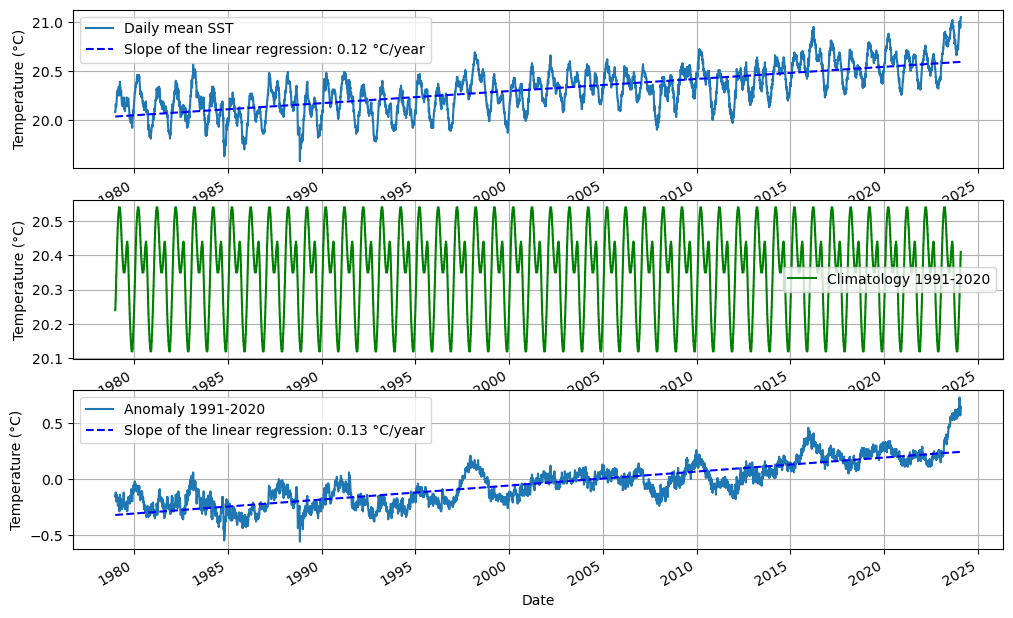

In [73]:
#Data from Copernicus : https://climate.copernicus.eu/copernicus-2024-world-experienced-warmest-january-record
# Open the CSV file
file_path = '/Users/epauthen/Documents/Database/timeseries_era5_daily_sst_60S-60N_data_2.csv'

# Load the CSV file into a DataFrame
data = pd.read_csv(file_path, delimiter=';')

# Convert DataFrame to xarray dataset
ds = xr.Dataset.from_dataframe(data)
ds = xr.Dataset.from_dataframe(data.set_index('date'))
ds['date'] = ds['date'].astype('datetime64')

# Plotting
fig, (ax1,ax2,ax3) = plt.subplots(3, 1,figsize = (12,7))

# Plotting sst
ds['sst'].plot(label='Daily mean SST',ax = ax1)
ds['clim_91-20'].plot(label='Climatology 1991-2020', color='green',ax = ax2)
ds['ano_91-20'].plot(label='Anomaly 1991-2020', color='tab:blue',ax = ax3)

# Linear regression for daily SST
x_values = np.arange(len(ds['date'])).reshape(-1, 1)
y_values = ds['sst'].values.reshape(-1, 1)
model = LinearRegression()
model.fit(x_values, y_values)
regression_line = model.predict(x_values)
slope = np.round(model.coef_[0][0]*3650,2)
ax1.plot(ds['date'], regression_line, label=f"Slope of the linear regression: {slope} °C/year", linestyle='--', color='blue')

# Linear regression for anomaly
x_values = np.arange(len(ds['date'])).reshape(-1, 1)
y_values = ds['ano_91-20'].values.reshape(-1, 1)
model = LinearRegression()
model.fit(x_values, y_values)
regression_line = model.predict(x_values)
slope = np.round(model.coef_[0][0]*3650,2)
ax3.plot(ds['date'], regression_line, label=f"Slope of the linear regression: {slope} °C/year", linestyle='--', color='blue')

#plt.title('Sea Surface Temperature Data')
for ax in (ax1,ax2,ax3):
    ax.set_xlabel('Date')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    ax.grid()